In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

In [ ]:
file_path = "/content/MULTI-SENSOR ANOMALY & CONDITION.xlsx"
df = pd.read_excel(file_path)

In [ ]:
features = [
    'Temperature',
    'Vibration',
    'Pressure',
    'EnergyConsumption',
    'ProductionUnits',
    'DefectCount',
    'MaintenanceFlag'
]


In [ ]:
df = df[features].copy()

In [ ]:
df = df.fillna(df.mean())

In [ ]:
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

In [ ]:
df_scaled['HealthScore'] = (
    100
    - (0.25 * df_scaled['Temperature'] * 100)
    - (0.25 * df_scaled['Vibration'] * 100)
    - (0.15 * df_scaled['Pressure'] * 100)
    - (0.15 * df_scaled['EnergyConsumption'] * 100)
    - (0.10 * df_scaled['DefectCount'] * 100)
    - (0.05 * df_scaled['MaintenanceFlag'] * 100)
    + (0.05 * df_scaled['ProductionUnits'] * 100)
)

In [ ]:
df_scaled['HealthScore'] = df_scaled['HealthScore'].clip(0, 100)

print("Sample Health Scores:")
print(df_scaled['HealthScore'].head())

Sample Health Scores:
0    63.196410
1    65.443261
2    56.177157
3    57.086222
4    68.732797
Name: HealthScore, dtype: float64


In [ ]:
X = df_scaled.drop(columns=['HealthScore'])
y = df_scaled['HealthScore']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

In [ ]:
model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("R2 Score:", r2)
print("MAE:", mae)

R2 Score: 0.9588337447918738
MAE: 0.8239696017902376



Feature Importance:
Vibration            0.330098
Temperature          0.299539
EnergyConsumption    0.112544
Pressure             0.104587
ProductionUnits      0.064687
MaintenanceFlag      0.052528
DefectCount          0.036018
dtype: float64


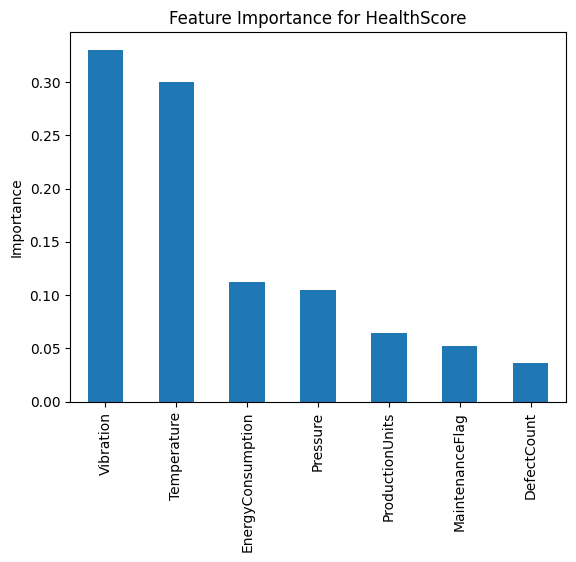

In [ ]:
import matplotlib.pyplot as plt


importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

print("\nFeature Importance:")
print(importance)

plt.figure()
importance.plot(kind='bar')
plt.title("Feature Importance for HealthScore")
plt.ylabel("Importance")
plt.show()

In [ ]:
import pickle

In [ ]:
with open('rf_health_model.pkl', 'wb') as f:
    pickle.dump(model, f)

In [ ]:
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("Model and scaler saved successfully!")

Model and scaler saved successfully!


In [ ]:
with open('rf_health_model.pkl', 'rb') as f:
    model = pickle.load(f)

with open('scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

print("Loaded successfully!")

Loaded successfully!
